# DeepLabV3–ResNet101 Oil Spill Segmentation Using Sentinel-1 SAR
### Clean Training Notebook — VV + VH, 5-Fold Training, Fine-Tuning, Holdout Evaluation

This notebook is a cleaned replacement for the previous DeepLab notebook. It keeps the same main variables and terminology:

`cfg`, `all_items`, `OilSpillDataset`, `BalancedOilSampler`, `build_model`, `loss_fn`,
`validate_with_calibration`, `RESUME`, `fold_summaries`, `BEST_FOLD`,
`FT_EPOCHS`, `FT_LR`, `test_oil_items`, `test_no_oil_items`, `test_look_items`,
`val_items`, `test_ds`, and `stats_test`.

**Architecture**
- DeepLabV3
- ResNet101 backbone
- 2 input channels: VV + VH
- 2 classes: 0 = background, 1 = oil

**Training**
- 5-fold cross-validation
- AdamW
- CosineAnnealingLR
- CE + 0.5 × Dice loss
- AMP
- IoU, F1, FAR, ECE, uncertainty monitoring

> The independent holdout test set is **not** added to `all_items`. It is loaded only after model selection, in the final inference section.



## Run Order

**New training:** run Sections 1–8 with `RESUME = False`.

**Resume training:** run Sections 1–8 with `RESUME = True`.

**Optional fine-tuning:** run Section 9 after the base K-fold run and choose `BEST_FOLD`.

**Final holdout evaluation:** select the checkpoint using validation results first, then run Sections 10–14.

Do not select a checkpoint or fine-tuning epoch using holdout test performance.

In [18]:
!pip -q install scikit-learn rasterio opencv-python matplotlib tqdm

In [19]:
import os
import csv
import gc
import random
from datetime import datetime
from dataclasses import dataclass, field
from typing import List, Dict

import numpy as np
import cv2
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.amp import GradScaler, autocast

from torchvision.models.segmentation import deeplabv3_resnet101
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, jaccard_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA: True
Using device: cuda


In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Experiment Configuration

The folder names and main hyperparameters remain aligned with the previous DeepLabV3–ResNet101 notebook.

In [21]:
@dataclass
class Cfg:
    drive_root: str = "/content/drive/MyDrive"
    data_dir: str = "/content/drive/MyDrive/Sentinel SAR datasets"

    # --- TRAINING SET FOLDERS ---
    oil_img_dir: str = "Oil"
    oil_mask_dir: str = "Mask_oil"
    no_oil_img_dir: str = "No_oil"
    no_oil_mask_dir: str = "Mask_no_oil"
    look_img_dir: str = "Lookalike"
    look_mask_dir: str = "Mask_lookalike"

    # --- HOLDOUT TEST SET ---
    # Configured here, but NOT loaded into all_items.
    test_img_dir: str = "02_Test_images_and_ground_truth/Images"
    test_mask_dir: str = "02_Test_images_and_ground_truth/Mask"

    test_oil_img_dir: str = "02_Test_images_and_ground_truth/Images/Oil"
    test_oil_mask_dir: str = "02_Test_images_and_ground_truth/Mask/Oil"
    test_no_oil_img_dir: str = "02_Test_images_and_ground_truth/Images/No oil"
    test_no_oil_mask_dir: str = "02_Test_images_and_ground_truth/Mask/No oil"
    test_look_img_dir: str = "02_Test_images_and_ground_truth/Images/Lookalike"
    test_look_mask_dir: str = "02_Test_images_and_ground_truth/Mask/Lookalike"

    out_dir: str = "/content/drive/MyDrive/oil_spill_checkpoints/periments/deepLabV3"

    num_classes: int = 2
    in_channels: int = 2
    epochs: int = 50
    batch_size: int = 8
    lr: float = 5e-4
    weight_decay: float = 1e-4
    crop_size: int = 512
    amp: bool = True
    seed: int = 1337

    k_folds: int = 5
    n_bins: int = 10

    log_file: str = field(init=False)

    def __post_init__(self):
        os.makedirs(self.out_dir, exist_ok=True)
        self.log_file = os.path.join(
            self.out_dir,
            "deepLab_resnet101_training_log_clean.csv"
        )


cfg = Cfg()

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

print("Dataset:", cfg.data_dir)
print("Output :", cfg.out_dir)
print("Seed   :", cfg.seed)

Dataset: /content/drive/MyDrive/Sentinel SAR datasets
Output : /content/drive/MyDrive/oil_spill_checkpoints/periments/deepLabV3
Seed   : 1337


# 3. Build Training / K-Fold Items

`all_items` contains only:
- `oil`
- `no_oil`
- `lookalike`

The independent holdout subsets `test_oil`, `test_no_oil`, and `test_look` are not loaded here.

In [22]:
def build_training_items(cfg: Cfg) -> List[Dict]:
    items = []

    def add_pairs(img_subdir, mask_subdir, label):
        img_dir = os.path.join(cfg.data_dir, img_subdir)
        mask_dir = os.path.join(cfg.data_dir, mask_subdir)

        assert os.path.isdir(img_dir), f"Missing folder: {img_dir}"
        assert os.path.isdir(mask_dir), f"Missing folder: {mask_dir}"

        for name in sorted(os.listdir(img_dir)):
            if not name.lower().endswith((".tif", ".tiff")):
                continue

            img_path = os.path.join(img_dir, name)
            base = os.path.splitext(name)[0]

            candidates = [
                os.path.join(mask_dir, base + ".png"),
                os.path.join(mask_dir, base + ".tif"),
                os.path.join(mask_dir, base + ".tiff"),
            ]

            mask_path = next((p for p in candidates if os.path.exists(p)), None)

            if mask_path is None:
                print(f"[WARN] No mask found for {img_path}")
                continue

            items.append({
                "img": img_path,
                "mask": mask_path,
                "subset": label,
                "name": name,
            })

    add_pairs(cfg.oil_img_dir, cfg.oil_mask_dir, "oil")
    add_pairs(cfg.no_oil_img_dir, cfg.no_oil_mask_dir, "no_oil")
    add_pairs(cfg.look_img_dir, cfg.look_mask_dir, "lookalike")

    print("=" * 60)
    print("DEEPLAB TRAINING / K-FOLD DATASET")
    print("=" * 60)
    print(f"Oil       : {sum(i['subset']=='oil' for i in items)}")
    print(f"No oil    : {sum(i['subset']=='no_oil' for i in items)}")
    print(f"Lookalike : {sum(i['subset']=='lookalike' for i in items)}")
    print(f"TOTAL     : {len(items)}")
    print("=" * 60)

    return items


all_items = build_training_items(cfg)

training_subsets = {item["subset"] for item in all_items}

for forbidden_subset in ("test_oil", "test_no_oil", "test_look"):
    assert forbidden_subset not in training_subsets, (
        f"DATA LEAKAGE DETECTED: {forbidden_subset} found in all_items."
    )

assert len(all_items) > 0, "No training data were loaded."

print("PASS: holdout test data are not in all_items.")

DEEPLAB TRAINING / K-FOLD DATASET
Oil       : 1200
No oil    : 685
Lookalike : 504
TOTAL     : 2389
PASS: holdout test data are not in all_items.


## 3.1 Optional Balanced Sampler

Retained from the previous notebook. The main training section defaults to normal shuffled sampling.

In [23]:
class BalancedOilSampler(Sampler):
    def __init__(self, items, target_probs=None, num_samples=None, seed=1337):
        self.items = items
        self.rng = random.Random(seed)

        if target_probs is None:
            target_probs = {
                "oil": 0.5,
                "no_oil": 0.25,
                "lookalike": 0.25,
            }

        self.labels = ["oil", "no_oil", "lookalike"]
        self.probs = [target_probs.get(label, 0.0) for label in self.labels]

        total = sum(self.probs)
        if total <= 0:
            raise ValueError("target_probs must have positive sum")

        self.probs = [p / total for p in self.probs]

        self.indices_by_subset = {label: [] for label in self.labels}

        for idx, item in enumerate(items):
            subset = item.get("subset")
            if subset in self.indices_by_subset:
                self.indices_by_subset[subset].append(idx)

        for label, p in zip(self.labels, self.probs):
            if p > 0 and len(self.indices_by_subset[label]) == 0:
                raise ValueError(f"No items for subset '{label}' but probability > 0")

        self.num_samples = len(items) if num_samples is None else num_samples

    def __iter__(self):
        for _ in range(self.num_samples):
            subset = self.rng.choices(self.labels, weights=self.probs, k=1)[0]
            yield self.rng.choice(self.indices_by_subset[subset])

    def __len__(self):
        return self.num_samples

# 4. Dataset Class

Same VV/VH handling and normalization:

```python
img = np.clip(img, -50, 5)
img = (img - (-22.5)) / 12.5
```

Training augmentation: flips, 90-degree rotations, small Gaussian perturbation, and mild contrast/brightness jitter.

In [24]:
class OilSpillDataset(Dataset):
    def __init__(self, items, crop_size=512, augment=True):
        self.items = items
        self.crop = crop_size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def _read_tiff_2ch(self, path):
        with rasterio.open(path) as ds:
            arr = ds.read()

        if arr.ndim == 3 and arr.shape[0] >= 2:
            arr = arr[:2]
        elif arr.ndim == 3 and arr.shape[0] == 1:
            arr = np.concatenate([arr, arr], axis=0)
        elif arr.ndim == 2:
            arr = np.stack([arr, arr], axis=0)
        else:
            raise ValueError(f"Unexpected TIFF shape {arr.shape} for {path}")

        return np.transpose(arr, (1, 2, 0)).astype(np.float32)

    def _read_mask(self, path):
        if path.lower().endswith((".tif", ".tiff")):
            with rasterio.open(path) as ds:
                m = ds.read(1)
        else:
            m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if m is None:
                raise ValueError(f"Could not read mask: {path}")

        return (m > 0).astype(np.uint8)

    def _random_crop(self, img, mask, size):
        H, W, _ = img.shape

        if H < size or W < size:
            pad_h = max(0, size - H)
            pad_w = max(0, size - W)

            img = cv2.copyMakeBorder(
                img, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT_101
            )
            mask = cv2.copyMakeBorder(
                mask, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0
            )
            H, W, _ = img.shape

        y = random.randint(0, H - size)
        x = random.randint(0, W - size)

        return img[y:y+size, x:x+size], mask[y:y+size, x:x+size]

    def _augs(self, img, mask):
        if self.augment:
            if random.random() < 0.5:
                img = np.ascontiguousarray(np.fliplr(img))
                mask = np.ascontiguousarray(np.fliplr(mask))

            if random.random() < 0.5:
                img = np.ascontiguousarray(np.flipud(img))
                mask = np.ascontiguousarray(np.flipud(mask))

            if random.random() < 0.5:
                k = random.choice([1, 2, 3])
                img = np.ascontiguousarray(np.rot90(img, k, axes=(0, 1)))
                mask = np.ascontiguousarray(np.rot90(mask, k, axes=(0, 1)))

            if random.random() < 0.3:
                noise = np.random.normal(0, 0.05, img.shape).astype(np.float32)
                img = np.clip(img + noise, -5.0, 5.0)

            if random.random() < 0.3:
                alpha = 1.0 + 0.2 * (2 * random.random() - 1)
                beta = 0.1 * (2 * random.random() - 1)
                img = alpha * img + beta

        return img, mask

    def __getitem__(self, idx):
        item = self.items[idx]

        img = self._read_tiff_2ch(item["img"])
        mask = self._read_mask(item["mask"])

        if img.shape[:2] != mask.shape:
            raise ValueError(
                f"Image/mask shape mismatch for {item['name']}: "
                f"{img.shape[:2]} vs {mask.shape}"
            )

        img = np.clip(img, -50, 5)
        img = (img - (-22.5)) / 12.5

        img, mask = self._augs(img, mask)

        if self.crop:
            img, mask = self._random_crop(img, mask, self.crop)

        img = np.transpose(img, (2, 0, 1)).astype(np.float32)

        return torch.from_numpy(img), torch.from_numpy(mask).long()

In [25]:
# Dataset sanity check

tmp_ds = OilSpillDataset(all_items, crop_size=None, augment=False)
x_check, y_check = tmp_ds[0]

print("Input :", x_check.shape, x_check.dtype)
print("Target:", y_check.shape, y_check.dtype)
print("Mask values:", torch.unique(y_check).tolist())

assert x_check.shape[0] == 2
assert y_check.ndim == 2
assert set(torch.unique(y_check).tolist()).issubset({0, 1})

print("PASS: dataset output is compatible with DeepLabV3.")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Input : torch.Size([2, 2048, 2048]) torch.float32
Target: torch.Size([2048, 2048]) torch.int64
Mask values: [0, 1]
PASS: dataset output is compatible with DeepLabV3.


# 5. DeepLabV3–ResNet101 Model and Loss

Canonical model definition used for both training and inference.

Loss:
`CrossEntropy + 0.5 × Dice`.

In [26]:
def build_model(cfg):
    model = deeplabv3_resnet101(
        weights=None,
        num_classes=cfg.num_classes
    )

    old_conv = model.backbone.conv1

    new_conv = nn.Conv2d(
        cfg.in_channels,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    nn.init.kaiming_normal_(
        new_conv.weight,
        mode="fan_out",
        nonlinearity="relu"
    )

    model.backbone.conv1 = new_conv

    return model


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0, ignore_index=255):
        super().__init__()
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)[:, 1]
        valid = (targets != self.ignore_index).float()
        targets_oil = (targets == 1).float()

        probs = probs * valid
        targets_oil = targets_oil * valid

        inter = (probs * targets_oil).sum(dim=(1, 2))
        denom = probs.sum(dim=(1, 2)) + targets_oil.sum(dim=(1, 2))

        dice_score = (2 * inter + self.smooth) / (denom + self.smooth)
        return 1 - dice_score.mean()


ce = nn.CrossEntropyLoss(ignore_index=255)
dice = DiceLoss(ignore_index=255)

def loss_fn(logits, targets):
    return ce(logits, targets) + 0.5 * dice(logits, targets)


model_check = build_model(cfg)
print("Input channels:", model_check.backbone.conv1.in_channels)
print("Classes:", cfg.num_classes)
assert model_check.backbone.conv1.in_channels == 2
del model_check
gc.collect()

Input channels: 2
Classes: 2


24111

# 6. Validation Metrics

Training validation uses:
- IoU
- F1
- FAR
- threshold-free ECE based on `P(oil)`
- mean `p(1-p)` uncertainty

The validation decision threshold is `0.5`. Final holdout evaluation can use another threshold such as `0.3`.

In [27]:
def metrics(logits, y):
    with torch.no_grad():
        pred = torch.argmax(logits, dim=1)

        tp = ((pred == 1) & (y == 1)).sum().item()
        tn = ((pred == 0) & (y == 0)).sum().item()
        fp = ((pred == 1) & (y == 0)).sum().item()
        fn = ((pred == 0) & (y == 1)).sum().item()

        iou = tp / max(1, tp + fp + fn)
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0 else 0.0
        )

    return {"IoU": iou, "F1": f1, "TP": tp, "FP": fp, "FN": fn, "TN": tn}


def validate_with_calibration(
    model,
    val_loader,
    device,
    n_bins=10,
    ignore_index=255,
    thr=0.5
):
    model.eval()

    total_loss = 0.0
    total_images = 0

    TP = FP = TN = FN = 0

    total_px = 0
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_pos_sum = np.zeros(n_bins, dtype=np.float64)
    uncertainty_sum = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)["out"]
            loss = loss_fn(logits, y)

            total_loss += loss.item() * x.size(0)
            total_images += x.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= thr).long()

            p_flat = probs.detach().cpu().numpy().ravel()
            y_flat = y.detach().cpu().numpy().ravel()
            pr_flat = preds.detach().cpu().numpy().ravel()

            if ignore_index is not None:
                valid = y_flat != ignore_index
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]

            if p_flat.size == 0:
                continue

            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            total_px += p_flat.size
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins - 1)

            for b in range(n_bins):
                m = bin_idx == b
                if not np.any(m):
                    continue

                bin_total[b] += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_pos_sum[b] += y_flat[m].sum()

            uncertainty_sum += np.sum(p_flat * (1.0 - p_flat))

    val_loss = total_loss / max(1, total_images)
    IoU = TP / max(1, TP + FP + FN)
    precision = TP / max(1, TP + FP)
    recall = TP / max(1, TP + FN)
    F1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    FAR = FP / max(1, FP + TN)

    ece = 0.0
    bin_acc = np.full(n_bins, np.nan, dtype=np.float64)
    bin_conf = np.full(n_bins, np.nan, dtype=np.float64)

    for b in range(n_bins):
        if bin_total[b] == 0:
            continue

        bin_conf[b] = bin_conf_sum[b] / bin_total[b]
        bin_acc[b] = bin_pos_sum[b] / bin_total[b]
        ece += (bin_total[b] / max(1, total_px)) * abs(bin_acc[b] - bin_conf[b])

    uncertainty_var = uncertainty_sum / max(1, total_px)

    return {
        "loss": float(val_loss),
        "IoU": float(IoU),
        "F1": float(F1),
        "FAR": float(FAR),
        "ECE": float(ece),
        "uncertainty_var": float(uncertainty_var),
        "TP": int(TP),
        "FP": int(FP),
        "TN": int(TN),
        "FN": int(FN),
        "bin_conf": bin_conf,
        "bin_acc": bin_acc,
        "bin_total": bin_total,
    }

# 7. Main 5-Fold Training

This is the only main training loop.

- `RESUME = False` for a new run.
- `RESUME = True` to continue compatible saved fold checkpoints.
- `USE_BALANCED_SAMPLER = False` keeps normal shuffled training.
- Best checkpoints are selected using **validation IoU only**.

In [28]:
RESUME = False
USE_BALANCED_SAMPLER = False

CHECKPOINT_PREFIX = "deeplabv3_resnet101_oil_mar10"
AMP_ENABLED = bool(cfg.amp and torch.cuda.is_available())

kfold = KFold(
    n_splits=cfg.k_folds,
    shuffle=True,
    random_state=cfg.seed
)

fold_summaries = []

if not os.path.isfile(cfg.log_file):
    with open(cfg.log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "timestamp", "fold", "epoch", "train_loss",
            "val_loss", "IoU", "F1", "FAR", "ECE", "uncertainty_var"
        ])


for fold, (train_idx, val_idx) in enumerate(kfold.split(all_items), start=1):
    print("\n" + "=" * 80)
    print(f"Fold {fold}/{cfg.k_folds}")
    print("=" * 80)

    train_items = [all_items[i] for i in train_idx]
    val_items = [all_items[i] for i in val_idx]

    train_paths = {item["img"] for item in train_items}
    val_paths = {item["img"] for item in val_items}
    assert train_paths.isdisjoint(val_paths)

    train_ds = OilSpillDataset(train_items, crop_size=cfg.crop_size, augment=True)
    val_ds = OilSpillDataset(val_items, crop_size=cfg.crop_size, augment=False)

    target_probs = {"oil": 0.5, "no_oil": 0.25, "lookalike": 0.25}

    if USE_BALANCED_SAMPLER:
        train_sampler = BalancedOilSampler(
            train_items,
            target_probs=target_probs,
            seed=cfg.seed + fold
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=cfg.batch_size,
            sampler=train_sampler,
            num_workers=2,
            pin_memory=True,
            drop_last=True
        )
    else:
        train_loader = DataLoader(
            train_ds,
            batch_size=cfg.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True,
            drop_last=True
        )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    ckpt_path = os.path.join(
        cfg.out_dir,
        f"{CHECKPOINT_PREFIX}_fold{fold}_continued_best.pt"
    )

    model = build_model(cfg).to(device)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=cfg.epochs
    )

    scaler = GradScaler("cuda", enabled=AMP_ENABLED)

    start_epoch = 1
    best_iou = -1.0
    best_metrics = None

    if RESUME and os.path.exists(ckpt_path):
        print(f"Resuming fold {fold} from {ckpt_path}")

        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        state = ckpt.get("state_dict", ckpt)
        state = {k.replace("module.", ""): v for k, v in state.items()}

        model.load_state_dict(state, strict=True)

        prev_epoch = ckpt.get("epoch", 0)
        best_metrics = ckpt.get("metrics", {})
        best_iou = best_metrics.get("IoU", -1.0)
        start_epoch = prev_epoch + 1

        print(f"Previous epoch: {prev_epoch}")
        print(f"Previous best IoU: {best_iou:.4f}")

        if start_epoch > cfg.epochs:
            print(f"Fold {fold} already complete.")

            fold_summaries.append({
                "fold": fold,
                "best_IoU": best_iou,
                "best_F1": best_metrics.get("F1", 0.0),
                "best_FAR": best_metrics.get("FAR", 0.0),
                "best_ECE": best_metrics.get("ECE", 0.0),
                "best_Uvar": best_metrics.get("uncertainty_var", 0.0),
                "checkpoint": ckpt_path,
            })

            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            continue

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        tr_loss = 0.0

        for x, y in tqdm(
            train_loader,
            desc=f"Fold {fold} Epoch {epoch}/{cfg.epochs} [train]"
        ):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                out = model(x)["out"]
                loss = loss_fn(out, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            tr_loss += loss.item() * x.size(0)

        tr_loss /= max(1, len(train_loader.dataset))
        sched.step()

        val_metrics = validate_with_calibration(
            model,
            val_loader,
            device,
            n_bins=cfg.n_bins,
            ignore_index=255,
            thr=0.5
        )

        print(
            f"Fold {fold} Epoch {epoch:03d} | "
            f"train {tr_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"IoU {val_metrics['IoU']:.4f} | "
            f"F1 {val_metrics['F1']:.4f} | "
            f"FAR {val_metrics['FAR']:.4f} | "
            f"ECE {val_metrics['ECE']:.4f} | "
            f"U_var {val_metrics['uncertainty_var']:.4f}"
        )

        with open(cfg.log_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(timespec="seconds"),
                fold,
                epoch,
                f"{tr_loss:.4f}",
                f"{val_metrics['loss']:.4f}",
                f"{val_metrics['IoU']:.4f}",
                f"{val_metrics['F1']:.4f}",
                f"{val_metrics['FAR']:.4f}",
                f"{val_metrics['ECE']:.4f}",
                f"{val_metrics['uncertainty_var']:.4f}",
            ])

        if val_metrics["IoU"] > best_iou:
            best_iou = val_metrics["IoU"]
            best_metrics = val_metrics

            torch.save({
                "state_dict": model.state_dict(),
                "cfg": vars(cfg),
                "fold": fold,
                "epoch": epoch,
                "metrics": best_metrics,
            }, ckpt_path)

            print(f"New best Fold {fold}: IoU={best_iou:.4f}")
            print(f"Saved: {ckpt_path}")

    if best_metrics is None:
        raise RuntimeError(f"No best metrics recorded for Fold {fold}.")

    fold_summaries.append({
        "fold": fold,
        "best_IoU": best_metrics["IoU"],
        "best_F1": best_metrics["F1"],
        "best_FAR": best_metrics["FAR"],
        "best_ECE": best_metrics["ECE"],
        "best_Uvar": best_metrics["uncertainty_var"],
        "checkpoint": ckpt_path,
    })

    del model, opt, sched, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n5-fold training complete.")


Fold 1/5


Fold 1 Epoch 1/50 [train]:   0%|          | 0/238 [00:01<?, ?it/s]


KeyboardInterrupt: 

# 8. Fold Summary

In [11]:
if not fold_summaries:
    print("No fold summaries available. Run the training section first.")
else:
    print("=" * 85)
    print(f"{'Fold':<6}{'IoU':<12}{'F1':<12}{'FAR':<12}{'ECE':<12}{'U_var':<12}")
    print("=" * 85)

    for row in fold_summaries:
        print(
            f"{row['fold']:<6}"
            f"{row['best_IoU']:<12.4f}"
            f"{row['best_F1']:<12.4f}"
            f"{row['best_FAR']:<12.4f}"
            f"{row['best_ECE']:<12.4f}"
            f"{row['best_Uvar']:<12.6f}"
        )

    best_fold_row = max(fold_summaries, key=lambda r: r["best_IoU"])

    print("=" * 85)
    print("Best validation fold:", best_fold_row["fold"])
    print("Best validation IoU :", f"{best_fold_row['best_IoU']:.4f}")
    print("Checkpoint          :", best_fold_row["checkpoint"])

NameError: name 'fold_summaries' is not defined

# 9. Optional Fine-Tuning

The selected fold's original training partition is used for fine-tuning and its original validation partition remains validation-only.

The holdout test set is still not loaded here.

In [ ]:
RUN_FINE_TUNING = False

BEST_FOLD = 3
FT_BATCH_SIZE = 8
FT_EPOCHS = 15
FT_LR = 1e-4

if RUN_FINE_TUNING:
    ckpt_path = os.path.join(
        cfg.out_dir,
        f"{CHECKPOINT_PREFIX}_fold{BEST_FOLD}_continued_best.pt"
    )

    assert os.path.exists(ckpt_path), f"Missing base checkpoint: {ckpt_path}"

    kfold = KFold(
        n_splits=cfg.k_folds,
        shuffle=True,
        random_state=cfg.seed
    )

    train_items = None
    val_items = None

    for fold, (train_idx, val_idx) in enumerate(kfold.split(all_items), start=1):
        if fold == BEST_FOLD:
            train_items = [all_items[i] for i in train_idx]
            val_items = [all_items[i] for i in val_idx]
            break

    assert train_items is not None
    assert val_items is not None

    train_paths = {item["img"] for item in train_items}
    val_paths = {item["img"] for item in val_items}
    assert train_paths.isdisjoint(val_paths)

    train_ds = OilSpillDataset(train_items, crop_size=cfg.crop_size, augment=True)
    val_ds = OilSpillDataset(val_items, crop_size=cfg.crop_size, augment=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=FT_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = build_model(cfg).to(device)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get("state_dict", ckpt)
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=FT_LR,
        weight_decay=cfg.weight_decay
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_EPOCHS)
    scaler = GradScaler("cuda", enabled=AMP_ENABLED)

    ft_log_file = os.path.join(
        cfg.out_dir,
        f"finetune_mar10_fold{BEST_FOLD}_log_clean.csv"
    )

    if not os.path.isfile(ft_log_file):
        with open(ft_log_file, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                "timestamp", "fold", "epoch", "train_loss",
                "val_loss", "IoU", "F1", "FAR", "ECE", "uncertainty_var"
            ])

    ft_ckpt_path = os.path.join(
        cfg.out_dir,
        f"{CHECKPOINT_PREFIX}_fold{BEST_FOLD}_finetuned_best.pt"
    )

    best_iou = -1.0
    best_metrics = None

    for epoch in range(1, FT_EPOCHS + 1):
        model.train()
        tr_loss = 0.0

        for x, y in tqdm(
            train_loader,
            desc=f"Fine-tune Fold {BEST_FOLD} Epoch {epoch}/{FT_EPOCHS}"
        ):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                out = model(x)["out"]
                loss = loss_fn(out, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            tr_loss += loss.item() * x.size(0)

        tr_loss /= max(1, len(train_loader.dataset))
        sched.step()

        val_metrics = validate_with_calibration(
            model,
            val_loader,
            device,
            n_bins=cfg.n_bins,
            ignore_index=255,
            thr=0.5
        )

        print(
            f"FT Epoch {epoch:03d} | "
            f"train {tr_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"IoU {val_metrics['IoU']:.4f} | "
            f"F1 {val_metrics['F1']:.4f} | "
            f"FAR {val_metrics['FAR']:.4f} | "
            f"ECE {val_metrics['ECE']:.4f}"
        )

        with open(ft_log_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(timespec="seconds"),
                BEST_FOLD,
                epoch,
                f"{tr_loss:.4f}",
                f"{val_metrics['loss']:.4f}",
                f"{val_metrics['IoU']:.4f}",
                f"{val_metrics['F1']:.4f}",
                f"{val_metrics['FAR']:.4f}",
                f"{val_metrics['ECE']:.4f}",
                f"{val_metrics['uncertainty_var']:.4f}",
            ])

        if val_metrics["IoU"] > best_iou:
            best_iou = val_metrics["IoU"]
            best_metrics = val_metrics

            torch.save({
                "state_dict": model.state_dict(),
                "cfg": vars(cfg),
                "fold": BEST_FOLD,
                "epoch": epoch,
                "metrics": best_metrics,
            }, ft_ckpt_path)

            print(f"Saved fine-tuned best: {ft_ckpt_path}")

    print("Fine-tuning complete.")
else:
    print("Fine-tuning skipped. Set RUN_FINE_TUNING=True to enable it.")

# 10. Load Selected Checkpoint

Choose `BEST_FOLD` from validation performance.  
Set `USE_FINETUNED=True` only if the fine-tuned checkpoint was intentionally created and selected from validation.

In [34]:
def load_deeplab_model(ckpt_path, device, in_ch=2, num_classes=2):
    model = build_model(cfg).to(device)

    assert model.backbone.conv1.in_channels == in_ch
    assert cfg.num_classes == num_classes
    assert os.path.exists(ckpt_path), f"Checkpoint not found: {ckpt_path}"

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    else:
        state = ckpt

    state = {k.replace("module.", ""): v for k, v in state.items()}

    # strict=True prevents accidental ResNet50 / incompatible loads.
    model.load_state_dict(state, strict=True)
    model.eval()

    return model


BEST_FOLD = 1
USE_FINETUNED = False

if USE_FINETUNED:
    ckpt_path = os.path.join(
        cfg.out_dir,
        f"{CHECKPOINT_PREFIX}_fold{BEST_FOLD}_finetuned_best.pt"
    )
else:
    ckpt_path = os.path.join(
        cfg.out_dir,
        f"deeplabv3_resnet101_oil_mar10_fold1_continued_best.pt"
        #f"{CHECKPOINT_PREFIX}_fold{BEST_FOLD}_continued_best.pt"
    )

print("Loading:", ckpt_path)

model = load_deeplab_model(
    ckpt_path,
    device=device,
    in_ch=2,
    num_classes=cfg.num_classes
)

print("Checkpoint loaded successfully.")

Loading: /content/drive/MyDrive/oil_spill_checkpoints/periments/deepLabV3/deeplabv3_resnet101_oil_mar10_fold1_continued_best.pt
Checkpoint loaded successfully.


# 11. Load Independent Holdout Test Data

This is the first point where holdout test folders are indexed.

The familiar variables remain:
- `test_oil_items`
- `test_no_oil_items`
- `test_look_items`

In [35]:
def build_test_items(cfg: Cfg) -> List[Dict]:
    items = []

    def add_pairs(img_subdir, mask_subdir, label):
        img_dir = os.path.join(cfg.data_dir, img_subdir)
        mask_dir = os.path.join(cfg.data_dir, mask_subdir)

        assert os.path.isdir(img_dir), f"Missing folder: {img_dir}"
        assert os.path.isdir(mask_dir), f"Missing folder: {mask_dir}"

        for name in sorted(os.listdir(img_dir)):
            if not name.lower().endswith((".tif", ".tiff")):
                continue

            img_path = os.path.join(img_dir, name)
            base = os.path.splitext(name)[0]

            candidate_bases = [base + "_segmentation", base]

            mask_path = None

            for candidate_base in candidate_bases:
                candidates = [
                    os.path.join(mask_dir, candidate_base + ".png"),
                    os.path.join(mask_dir, candidate_base + ".tif"),
                    os.path.join(mask_dir, candidate_base + ".tiff"),
                ]

                mask_path = next(
                    (p for p in candidates if os.path.exists(p)),
                    None
                )

                if mask_path is not None:
                    break

            if mask_path is None:
                print(f"[WARN] No holdout mask found for {img_path}")
                continue

            items.append({
                "img": img_path,
                "mask": mask_path,
                "subset": label,
                "name": name,
            })

    add_pairs(cfg.test_oil_img_dir, cfg.test_oil_mask_dir, "test_oil")
    add_pairs(cfg.test_no_oil_img_dir, cfg.test_no_oil_mask_dir, "test_no_oil")
    add_pairs(cfg.test_look_img_dir, cfg.test_look_mask_dir, "test_look")

    return items


test_items = build_test_items(cfg)

test_oil_items = [i for i in test_items if i["subset"] == "test_oil"]
test_no_oil_items = [i for i in test_items if i["subset"] == "test_no_oil"]
test_look_items = [i for i in test_items if i["subset"] == "test_look"]

print("=" * 60)
print("INDEPENDENT HOLDOUT TEST SET")
print("=" * 60)
print("Oil       :", len(test_oil_items))
print("No oil    :", len(test_no_oil_items))
print("Lookalike :", len(test_look_items))
print("TOTAL     :", len(test_items))
print("=" * 60)

training_paths = {os.path.abspath(i["img"]) for i in all_items}
test_paths = {os.path.abspath(i["img"]) for i in test_items}

assert training_paths.isdisjoint(test_paths), (
    "DATA LEAKAGE DETECTED: training and holdout image paths overlap."
)

print("PASS: training and holdout paths are separate.")

INDEPENDENT HOLDOUT TEST SET
Oil       : 150
No oil    : 150
Lookalike : 150
TOTAL     : 450
PASS: training and holdout paths are separate.


# 12. Inference Metrics and Visualization

For the two-class DeepLab model, prediction uses `P(oil) > thr`, so `thr=0.3` is actually applied.

In [36]:
def compute_iou_f1(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    iou = jaccard_score(
        y_true, y_pred, average="binary", zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred, average="binary", zero_division=0
    )

    return float(iou), float(f1)


def compute_far(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))

    return float(fp / max(1, fp + tn))


def compute_ece(probs, labels, n_bins=10):
    probs = np.asarray(probs).ravel()
    labels = np.asarray(labels).ravel()

    bin_idx = np.minimum((probs * n_bins).astype(int), n_bins - 1)
    ece = 0.0

    for b in range(n_bins):
        m = bin_idx == b
        if not np.any(m):
            continue

        conf = probs[m].mean()
        obs = labels[m].mean()
        ece += (m.sum() / max(1, probs.size)) * abs(obs - conf)

    return float(ece)


def viz_batch_metrics(x, y, pred_logits, thr=0.3, show_metrics=True):
    x_np = x.detach().cpu().numpy()

    if y.ndim == 4:
        y = y.squeeze(1)

    y_np = y.detach().cpu().numpy()

    probs = (
        torch.softmax(pred_logits, dim=1)[:, 1]
        .detach()
        .cpu()
        .numpy()
    )

    pred = (probs > thr).astype(np.uint8)

    for i in range(min(3, x_np.shape[0])):
        vv = x_np[i, 0]
        vh = x_np[i, 1]

        vv = (vv - vv.min()) / (vv.max() - vv.min() + 1e-6)
        vh = (vh - vh.min()) / (vh.max() - vh.min() + 1e-6)

        plt.figure(figsize=(15, 4))

        plt.subplot(1, 5, 1)
        plt.imshow(vv, cmap="gray")
        plt.title("VV")
        plt.axis("off")

        plt.subplot(1, 5, 2)
        plt.imshow(vh, cmap="gray")
        plt.title("VH")
        plt.axis("off")

        plt.subplot(1, 5, 3)
        plt.imshow(y_np[i], cmap="gray")
        plt.title("GT Mask")
        plt.axis("off")

        plt.subplot(1, 5, 4)
        plt.imshow(pred[i], cmap="gray")
        plt.title(f"Pred Mask\nthr={thr}")
        plt.axis("off")

        plt.subplot(1, 5, 5)
        plt.imshow((pred[i] > 0) & (y_np[i] == 0), cmap="Reds")
        plt.title("False Positives")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        if show_metrics:
            iou, f1 = compute_iou_f1(y_np[i], pred[i])
            far = compute_far(y_np[i], pred[i])
            ece = compute_ece(probs[i], y_np[i], n_bins=cfg.n_bins)

            print(
                f"Image {i}: IoU={iou:.4f}, F1={f1:.4f}, "
                f"FAR={far:.4f}, ECE={ece:.4f}"
            )

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


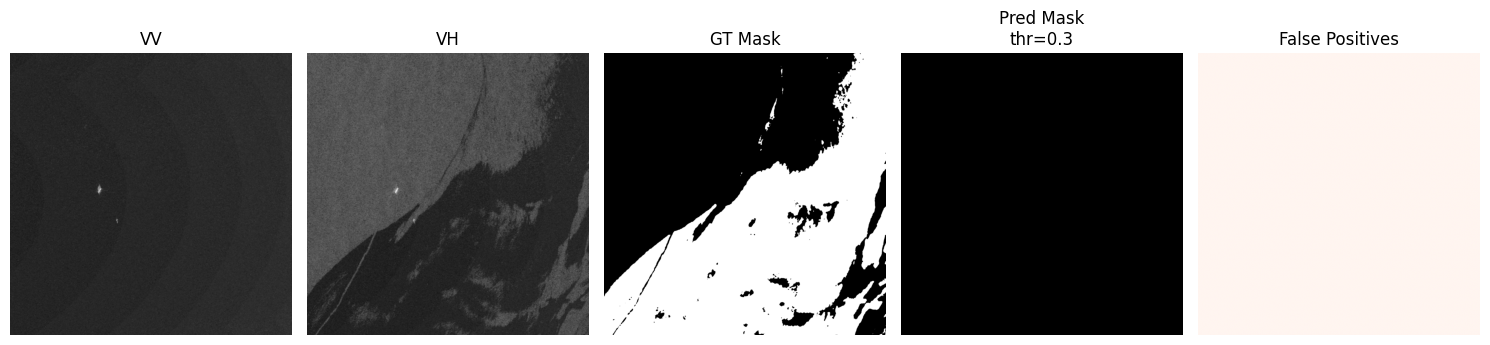

Image 0: IoU=0.0000, F1=0.0000, FAR=0.0000, ECE=0.4805


In [38]:
# Single holdout image example

val_items = [test_oil_items[0]]

val_ds = OilSpillDataset(
    val_items,
    crop_size=None,
    augment=False
)

model.eval()

with torch.no_grad():
    for x, y in DataLoader(val_ds, batch_size=1, shuffle=False):
        x = x.to(device)
        y = y.to(device)

        out = model(x)["out"]

        viz_batch_metrics(
            x,
            y,
            out,
            thr=0.3,
            show_metrics=True
        )
        break

# 13. Final Holdout Evaluation — IoU, F1, FAR, ECE, MC Dropout

Threshold-dependent:
- mIoU
- mF1
- FAR

Threshold-free:
- ECE / reliability based on `P(oil)`

MC Dropout:
- `mc_passes=0` gives deterministic inference.
- `mc_passes>1` enables repeated stochastic passes.

In [39]:
_DROPOUT_TYPES = (
    torch.nn.Dropout,
    torch.nn.Dropout2d,
    torch.nn.Dropout3d,
    torch.nn.AlphaDropout,
    torch.nn.FeatureAlphaDropout,
)


def _set_dropout_p(model, p):
    changed = []

    for m in model.modules():
        if isinstance(m, _DROPOUT_TYPES):
            old_p = getattr(m, "p", None)

            if old_p is not None:
                changed.append((m, old_p))
                m.p = p

    return changed


def _restore_dropout_p(changed):
    for m, old_p in changed:
        m.p = old_p


def _enable_dropout_only(model):
    for m in model.modules():
        if isinstance(m, _DROPOUT_TYPES):
            m.train()


def plot_reliability_from_bins_prob(
    bin_conf,
    bin_acc,
    title="Reliability Diagram (threshold-free)"
):
    valid = ~np.isnan(bin_conf) & ~np.isnan(bin_acc)

    plt.figure(figsize=(4, 4))
    plt.plot([0, 1], [0, 1], "--", label="Perfect")
    plt.plot(bin_conf[valid], bin_acc[valid], marker="o", label="Model")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def evaluate_dataset_miou_f1_mc_dropout(
    model,
    dataset,
    device,
    thr=0.3,
    batch_size=3,
    n_bins=10,
    ignore_index=None,
    mc_passes=20,
    mc_unbiased_var=False,
    plot_reliability=True,
    reliability_title="Reliability Diagram (P(oil), threshold-free)",
    dropout_p=0.2
):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()

    changed = []
    if dropout_p is not None:
        changed = _set_dropout_p(model, float(dropout_p))

    if mc_passes and mc_passes > 1:
        _enable_dropout_only(model)

    all_iou = []
    all_f1 = []

    TP = FP = TN = FN = 0

    total_px = 0
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_pos_sum = np.zeros(n_bins, dtype=np.float64)

    mc_var_sum = 0.0
    mc_var_px = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            if y.ndim == 4:
                y = y.squeeze(1)

            if mc_passes and mc_passes > 1:
                mean = None
                M2 = None

                for t in range(mc_passes):
                    logits_t = model(x)["out"]
                    probs_t = F.softmax(logits_t, dim=1)[:, 1]

                    if mean is None:
                        mean = probs_t.clone()
                        M2 = torch.zeros_like(probs_t)
                    else:
                        delta = probs_t - mean
                        mean = mean + delta / (t + 1)
                        delta2 = probs_t - mean
                        M2 = M2 + delta * delta2

                probs = mean
                denom = (mc_passes - 1) if mc_unbiased_var else mc_passes
                var_map = M2 / max(1, denom)

            else:
                logits = model(x)["out"]
                probs = F.softmax(logits, dim=1)[:, 1]
                var_map = torch.zeros_like(probs)

            preds = (probs > thr).long()

            y_np = y.detach().cpu().numpy()
            pr_np = preds.detach().cpu().numpy()
            p_np = probs.detach().cpu().numpy()
            v_np = var_map.detach().cpu().numpy()

            for i in range(pr_np.shape[0]):
                iou, f1 = compute_iou_f1(y_np[i], pr_np[i])
                all_iou.append(iou)
                all_f1.append(f1)

            p_flat = p_np.ravel()
            y_flat = y_np.ravel()
            pr_flat = pr_np.ravel()
            v_flat = v_np.ravel()

            if ignore_index is not None:
                valid = y_flat != ignore_index
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]
                v_flat = v_flat[valid]

            if p_flat.size == 0:
                continue

            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            total_px += p_flat.size
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins - 1)

            for b in range(n_bins):
                m = bin_idx == b
                if not np.any(m):
                    continue

                bin_total[b] += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_pos_sum[b] += y_flat[m].sum()

            mc_var_sum += float(np.sum(v_flat))
            mc_var_px += int(v_flat.size)

    miou = float(np.mean(all_iou)) if all_iou else 0.0
    mf1 = float(np.mean(all_f1)) if all_f1 else 0.0
    FAR = FP / max(1, FP + TN)

    ece = 0.0
    bin_acc = np.full(n_bins, np.nan, dtype=np.float64)
    bin_conf = np.full(n_bins, np.nan, dtype=np.float64)

    for b in range(n_bins):
        if bin_total[b] == 0:
            continue

        bin_conf[b] = bin_conf_sum[b] / bin_total[b]
        bin_acc[b] = bin_pos_sum[b] / bin_total[b]

        ece += (
            bin_total[b] / max(1, total_px)
        ) * abs(bin_acc[b] - bin_conf[b])

    mc_uncertainty_var = mc_var_sum / max(1, mc_var_px)

    print(f"mIoU over {len(all_iou)} images: {miou:.4f}")
    print(f"mF1  over {len(all_f1)} images: {mf1:.4f}")
    print(f"FAR  over all pixels       : {FAR:.4f} (thr={thr})")
    print(f"ECE (threshold-free, P(oil)): {ece:.4f}")
    print(
        f"MC Dropout var P(oil)      : {mc_uncertainty_var:.6f} "
        f"(passes={mc_passes}, dropout_p={dropout_p})"
    )

    if plot_reliability:
        plot_reliability_from_bins_prob(
            bin_conf,
            bin_acc,
            title=reliability_title
        )

    if changed:
        _restore_dropout_p(changed)

    model.eval()

    return {
        "mIoU": miou,
        "mF1": mf1,
        "FAR": float(FAR),
        "ECE": float(ece),
        "mc_uncertainty_var": float(mc_uncertainty_var),
        "TP": int(TP),
        "FP": int(FP),
        "TN": int(TN),
        "FN": int(FN),
        "bin_conf": bin_conf,
        "bin_acc": bin_acc,
        "bin_total": bin_total,
    }

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

mIoU over 150 images: 0.5486
mF1  over 150 images: 0.6380
FAR  over all pixels       : 0.0095 (thr=0.3)
ECE (threshold-free, P(oil)): 0.0616
MC Dropout var P(oil)      : 0.000000 (passes=0, dropout_p=0.2)


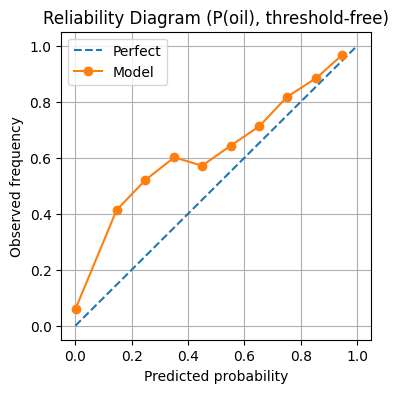

{'mIoU': 0.5485574796002672, 'mF1': 0.6380359586974077, 'FAR': 0.009521755608317427, 'ECE': 0.061565220416320406, 'mc_uncertainty_var': 0.0, 'TP': 24315869, 'FP': 5395442, 'TN': 561248171, 'FN': 38186118, 'bin_conf': array([6.35588305e-04, 1.46275070e-01, 2.48831295e-01, 3.50876815e-01,
       4.49440631e-01, 5.50806646e-01, 6.52662861e-01, 7.50872856e-01,
       8.55329512e-01, 9.47772618e-01]), 'bin_acc': array([0.06034771, 0.41302262, 0.52070088, 0.60140644, 0.57132367,
       0.64283633, 0.71223238, 0.81713526, 0.88483228, 0.96784991]), 'bin_total': array([5.94393923e+08, 2.86702700e+06, 2.17333800e+06, 2.16305300e+06,
       2.34923400e+06, 2.44358000e+06, 3.26062400e+06, 4.23058600e+06,
       5.42982900e+06, 9.83440600e+06])}


In [40]:
# Choose the final holdout group.

val_items = test_oil_items

# Alternatives:
# val_items = test_no_oil_items
# val_items = test_look_items
# val_items = test_oil_items + test_no_oil_items + test_look_items

test_ds = OilSpillDataset(
    val_items,
    crop_size=None,
    augment=False
)

stats_test = evaluate_dataset_miou_f1_mc_dropout(
    model,
    test_ds,
    device,
    thr=0.3,
    batch_size=3,
    n_bins=10,
    ignore_index=255,
    mc_passes=0,
    mc_unbiased_var=False,
    plot_reliability=True,
    reliability_title="Reliability Diagram (P(oil), threshold-free)",
    dropout_p=0.2
)

print(stats_test)

# 14. Look-Alike False-Positive Analysis

This section always uses the independent `test_look_items` dataset.

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


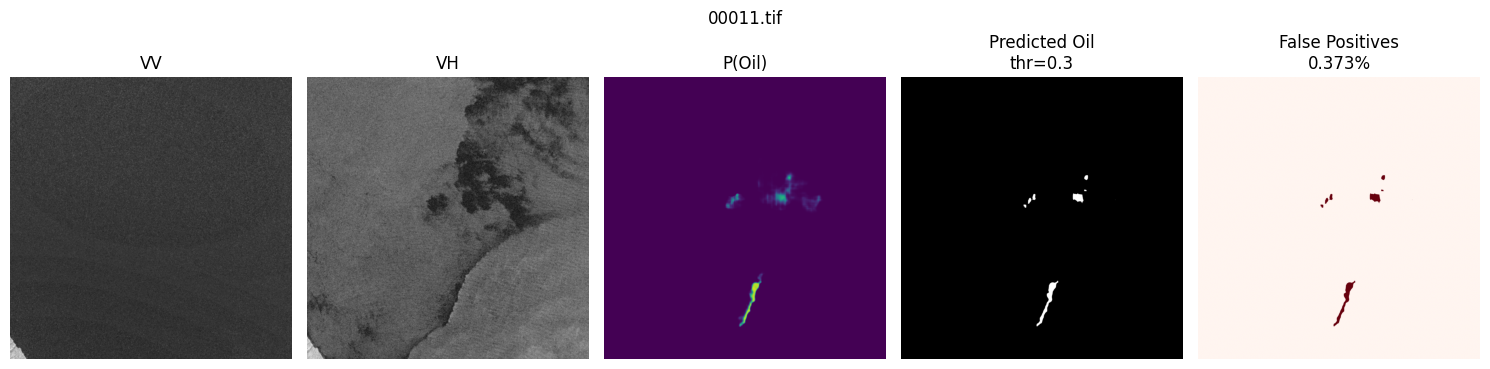

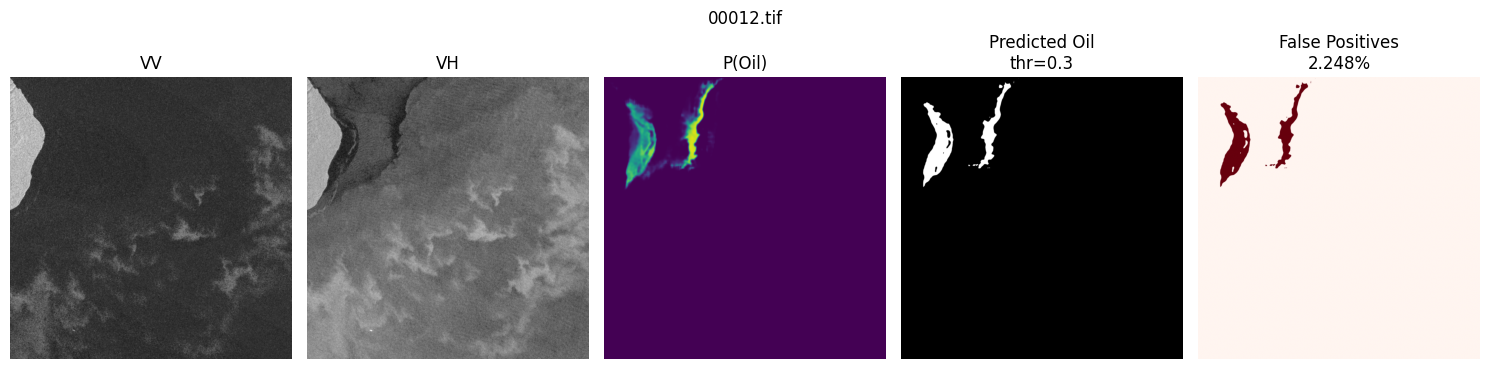

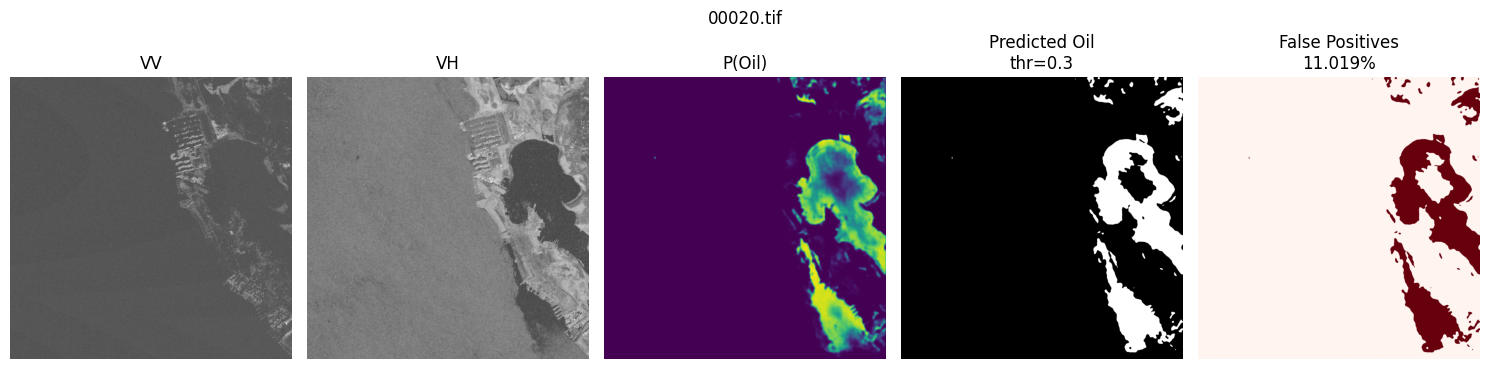

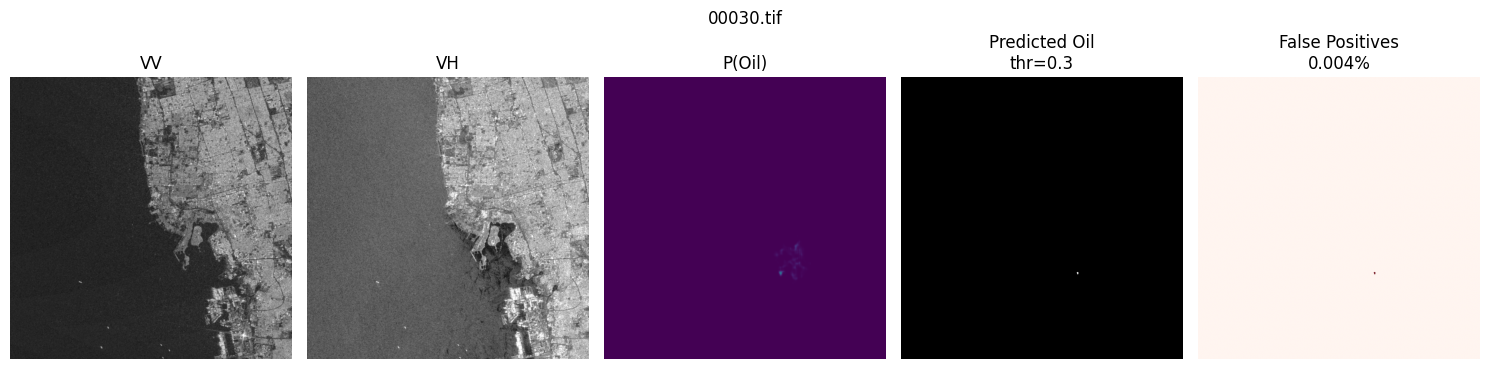

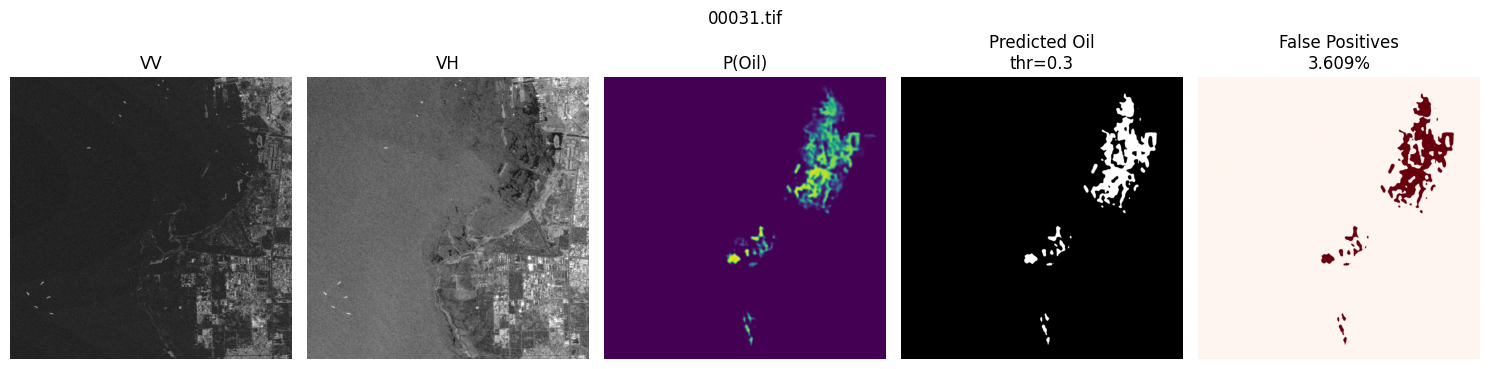

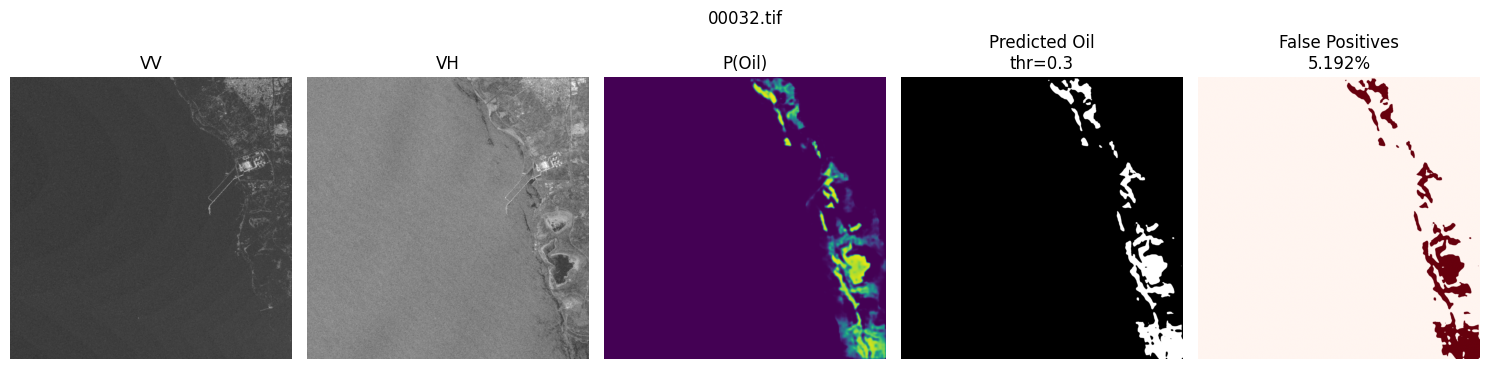

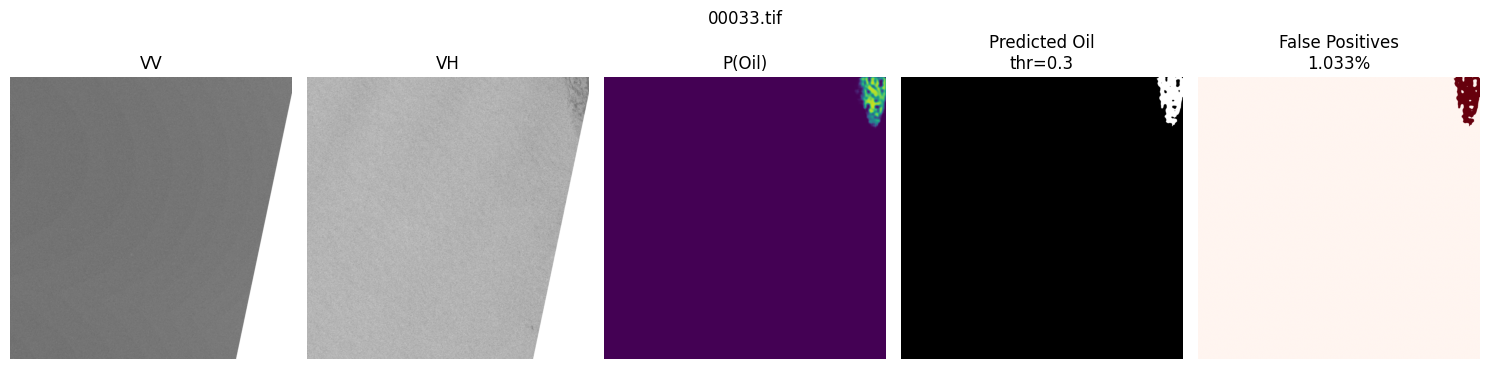

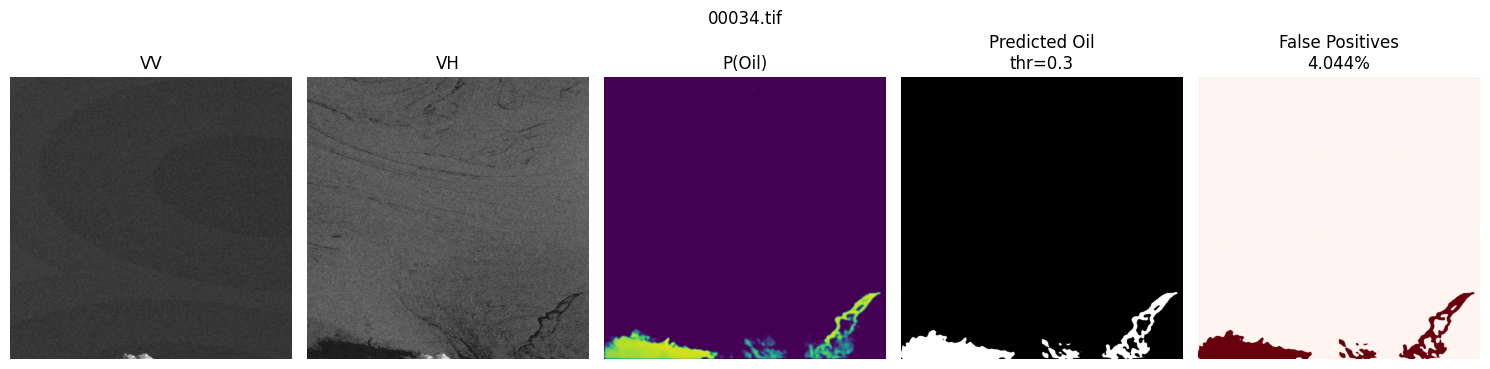

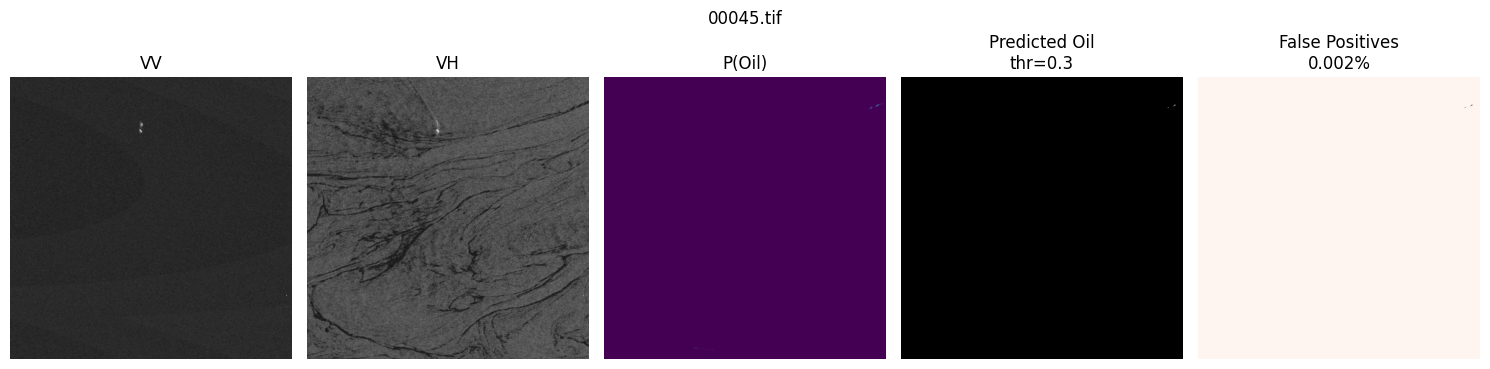

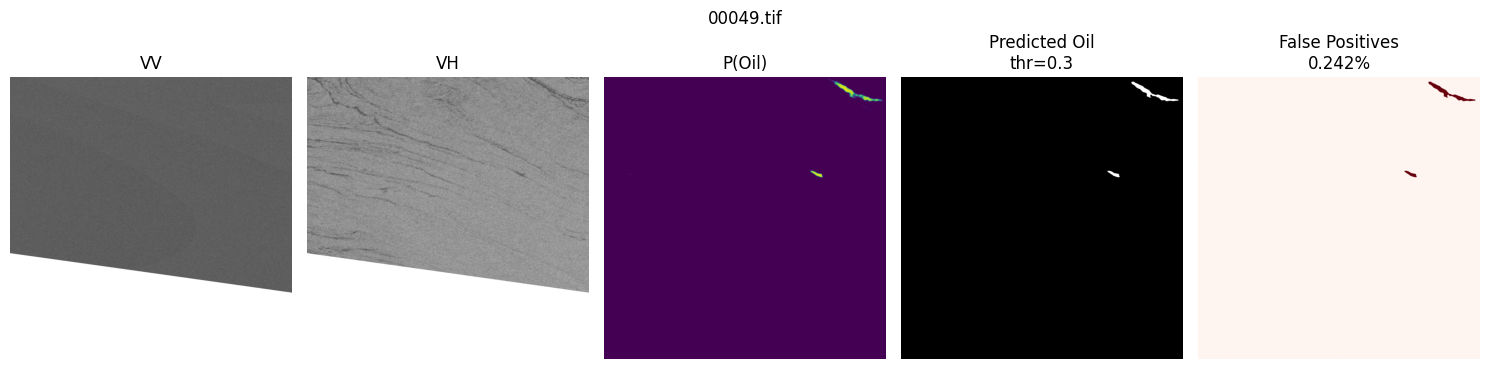

LOOK-ALIKE FALSE POSITIVE ANALYSIS
Threshold                       : 0.3
Total look-alike images         : 150
Images with false oil detection: 21/150
Image-level FP detection rate   : 14.00%
Total background pixels         : 629,145,600
False-positive oil pixels       : 3,189,270
Overall FP pixel rate           : 0.5069%
Mean FP pixels per image (%)    : 0.5069%
Ground-truth oil pixels found   : 0


In [41]:
def evaluate_lookalike_false_positives(
    model,
    dataset,
    device,
    thr=0.3,
    ignore_index=255,
    show_images=True,
    max_show=10,
    min_fp_pixels=1
):
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    model.eval()

    total_images = 0
    images_with_fp = 0

    total_fp_pixels = 0
    total_background_pixels = 0
    total_gt_oil_pixels = 0

    per_image_results = []
    shown = 0

    with torch.no_grad():
        for idx, (x, y) in enumerate(loader):
            x = x.to(device)
            y = y.to(device)

            if y.ndim == 4:
                y = y.squeeze(1)

            logits = model(x)["out"]
            probs = F.softmax(logits, dim=1)[:, 1]
            preds = (probs > thr).long()

            y_i = y[0]
            pred_i = preds[0]
            prob_i = probs[0]

            valid = (
                y_i != ignore_index
                if ignore_index is not None
                else torch.ones_like(y_i, dtype=torch.bool)
            )

            fp_mask = (pred_i == 1) & (y_i == 0) & valid
            background_mask = (y_i == 0) & valid
            gt_oil_mask = (y_i == 1) & valid

            fp_pixels = fp_mask.sum().item()
            background_pixels = background_mask.sum().item()
            gt_oil_pixels = gt_oil_mask.sum().item()

            total_images += 1
            total_fp_pixels += fp_pixels
            total_background_pixels += background_pixels
            total_gt_oil_pixels += gt_oil_pixels

            detected = fp_pixels >= min_fp_pixels

            if detected:
                images_with_fp += 1

            fp_pixel_percent = (
                100.0 * fp_pixels / max(1, background_pixels)
            )

            item_name = (
                dataset.items[idx].get("name", f"image_{idx}")
                if hasattr(dataset, "items")
                else f"image_{idx}"
            )

            per_image_results.append({
                "image": item_name,
                "fp_pixels": fp_pixels,
                "background_pixels": background_pixels,
                "fp_pixel_percent": fp_pixel_percent,
                "detected_as_oil": detected,
            })

            if show_images and detected and shown < max_show:
                x_np = x[0].detach().cpu().numpy()
                pred_np = pred_i.detach().cpu().numpy()
                prob_np = prob_i.detach().cpu().numpy()
                fp_np = fp_mask.detach().cpu().numpy()

                vv = x_np[0]
                vh = x_np[1]

                vv = (vv - vv.min()) / (vv.max() - vv.min() + 1e-6)
                vh = (vh - vh.min()) / (vh.max() - vh.min() + 1e-6)

                plt.figure(figsize=(15, 4))

                plt.subplot(1, 5, 1)
                plt.imshow(vv, cmap="gray")
                plt.title("VV")
                plt.axis("off")

                plt.subplot(1, 5, 2)
                plt.imshow(vh, cmap="gray")
                plt.title("VH")
                plt.axis("off")

                plt.subplot(1, 5, 3)
                plt.imshow(prob_np, cmap="viridis", vmin=0, vmax=1)
                plt.title("P(Oil)")
                plt.axis("off")

                plt.subplot(1, 5, 4)
                plt.imshow(pred_np, cmap="gray")
                plt.title(f"Predicted Oil\nthr={thr}")
                plt.axis("off")

                plt.subplot(1, 5, 5)
                plt.imshow(fp_np, cmap="Reds")
                plt.title(f"False Positives\n{fp_pixel_percent:.3f}%")
                plt.axis("off")

                plt.suptitle(item_name)
                plt.tight_layout()
                plt.show()

                shown += 1

    image_fp_rate = 100.0 * images_with_fp / max(1, total_images)

    overall_fp_pixel_rate = (
        100.0 * total_fp_pixels / max(1, total_background_pixels)
    )

    mean_fp_percent = (
        float(np.mean([r["fp_pixel_percent"] for r in per_image_results]))
        if per_image_results else 0.0
    )

    print("=" * 65)
    print("LOOK-ALIKE FALSE POSITIVE ANALYSIS")
    print("=" * 65)
    print(f"Threshold                       : {thr}")
    print(f"Total look-alike images         : {total_images}")
    print(f"Images with false oil detection: {images_with_fp}/{total_images}")
    print(f"Image-level FP detection rate   : {image_fp_rate:.2f}%")
    print(f"Total background pixels         : {total_background_pixels:,}")
    print(f"False-positive oil pixels       : {total_fp_pixels:,}")
    print(f"Overall FP pixel rate           : {overall_fp_pixel_rate:.4f}%")
    print(f"Mean FP pixels per image (%)    : {mean_fp_percent:.4f}%")
    print(f"Ground-truth oil pixels found   : {total_gt_oil_pixels:,}")
    print("=" * 65)

    return {
        "total_images": total_images,
        "images_with_fp": images_with_fp,
        "image_fp_rate_percent": image_fp_rate,
        "total_background_pixels": total_background_pixels,
        "total_fp_pixels": total_fp_pixels,
        "overall_fp_pixel_rate_percent": overall_fp_pixel_rate,
        "mean_fp_pixel_percent_per_image": mean_fp_percent,
        "ground_truth_oil_pixels": total_gt_oil_pixels,
        "per_image": per_image_results,
    }


look_ds = OilSpillDataset(
    test_look_items,
    crop_size=None,
    augment=False
)

look_fp_stats = evaluate_lookalike_false_positives(
    model,
    look_ds,
    device,
    thr=0.3,
    ignore_index=255,
    show_images=True,
    max_show=10,
    min_fp_pixels=1
)

## Final Checklist

Before reporting thesis results, confirm:

- `all_items` contains only `oil`, `no_oil`, and `lookalike`.
- K-fold numbering is 1–5.
- Holdout test folders are first loaded in Section 11.
- `BEST_FOLD` is selected from validation results.
- The final threshold is explicitly recorded.
- `mc_passes` is explicitly recorded.
- Look-alike false-positive image rate and pixel rate are reported separately.